#### Source Kaggle: https://www.kaggle.com/datasets/hubertsidorowicz/steam-games-dataset-daily-updates

In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, AnyStr
import ast

In [2]:
df = pd.read_csv("steam_games.csv", low_memory=False)
columns: List[AnyStr] = ['app_id', 'name', 'release_date', 'price', 'price_status', 'estimated_owners', 'developers', 'publishers', 'genres', 'categories',
'tags', 'positive', 'negative', 'recommendations', 'average_playtime_forever', 'median_playtime_forever', 'average_playtime_2weeks', 'median_playtime_2weeks', 'short_description', 'about_the_game',
'detailed_description', 'supported_languages', 'windows','mac', 'linux', 'steam_store_available', 'steam_spy_available']

pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

df = df.loc[:, columns]
df.shape

(139953, 27)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139953 entries, 0 to 139952
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    139953 non-null  int64  
 1   name                      139936 non-null  str    
 2   release_date              139870 non-null  str    
 3   price                     138774 non-null  float64
 4   price_status              139953 non-null  str    
 5   estimated_owners          139953 non-null  str    
 6   developers                139953 non-null  str    
 7   publishers                139953 non-null  str    
 8   genres                    139953 non-null  str    
 9   categories                139953 non-null  str    
 10  tags                      139953 non-null  str    
 11  positive                  139953 non-null  int64  
 12  negative                  139953 non-null  int64  
 13  recommendations           107646 non-null  float64
 14 

## Filters

In [4]:
# #Using custom filters for better insights:
# name_filt = df.name.str.contains("race", na=False, case=False)

# tags = "|".join(["Simulations", "Racing", "Race", "Action"])
# tag_filt = df.tags.str.contains(tags, case=False, na=False, regex=True)

# conditions = name_filt | tag_filt
# df = df.loc[conditions].reset_index(drop=True)
# df

### Cleaning Release Date Column:

In [5]:
# NA value fill with research value for the game: For this case, we have only one value NA
df.loc[df.release_date.isna(), 'release_date'] = '2011-03-15'

In [6]:
#Converting into datetime:
df['release_date'] = pd.to_datetime(df['release_date'], format="%Y-%m-%d")

# Assgning year for better grouping in future:
df['year'] = df.release_date.dt.year

# Assigning Catetogies:
df['price_status'] = df['price_status'].astype("category")
df['estimated_owners'] = df['estimated_owners'].astype("category")

In [7]:
df.head(2)

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,recommendations,average_playtime_forever,median_playtime_forever,average_playtime_2weeks,median_playtime_2weeks,short_description,about_the_game,detailed_description,supported_languages,windows,mac,linux,steam_store_available,steam_spy_available,year
0,886780,Jelly Wrestle,2018-07-28,2.99,paid,0 - 20000,"[""Fury Games Production""]","[""Fury Games Production""]","[""Action"", ""Adventure"", ""Casual"", ""Indie"", ""Si...","[""Single-player"", ""Steam Achievements"", ""Parti...","[""Action"", ""Indie"", ""Casual"", ""Simulation"", ""S...",2,0,0.0,0,0,0,0,Be a part of the battle in the fairy world of ...,Open the world filled with amazing jelly heroe...,Open the world filled with amazing jelly heroe...,"[""English"", ""Russian""]",True,False,False,True,True,2018
1,886820,Nelke & the Legendary Alchemists ~Ateliers of ...,2019-03-25,59.99,paid,20000 - 50000,"[""KOEI TECMO GAMES CO., LTD.""]","[""KOEI TECMO GAMES CO., LTD.""]","[""RPG""]","[""Single-player"", ""Steam Achievements"", ""Parti...","[""RPG"", ""City Builder"", ""Anime"", ""Female Prota...",208,61,227.0,450,227,0,0,Atelier 20th Anniversary Title An Atelier town...,Atelier 20th Anniversary Title An Atelier town...,Crossover characters are from these games: Ate...,"[""English"", ""Traditional Chinese"", ""Japanese""]",True,False,False,True,True,2019


### Cleaning of Estimated_Owners:

In [8]:
# Override commas and .. to ideal values:
df.estimated_owners = df.estimated_owners.str.replace(",", "")
df.estimated_owners = df.estimated_owners.str.replace("..", "-")

# Dropping rows for unwanted categories:
df.drop(df[df.estimated_owners == "0 - 0"].index, inplace=True)

# Value Counts Categories:
df.estimated_owners.value_counts()

# Reset index
df.reset_index(drop=True, inplace=True)

#### Cleaning Developers column:

In [9]:
# Replcing NaN and Empty values to Unknown:
df.loc[df.developers == '[]', 'developers'] = 'Unknown'


# Removing, replacing unwanted characters like []"",
df.loc[:, 'developers'] = df.developers.str.strip("[]").str.replace({'"': '', ',': ' and'})

#### Cleaning Publisher column:

In [10]:
# Replcing Empty values to Unknown:
df.loc[df.publishers == '[]', 'publishers'] = 'Unknown'


# Removing, replacing unwanted characters like []"",
df.loc[:, 'publishers'] = df.publishers.str.strip("[]").str.replace({'"': '', ',': ' and'})

df.reset_index(drop=True, inplace=True)

#### Cleaning and Processing Genres column:

In [11]:
# Genres are mixed column values where List and Dict can be found inside string values I can observe, Better to create separate custom logic function here.

import json 

# Assigning unique genre value in different dataframe:
gen_df = df.loc[df.genres.str.contains('{'), 'genres'].sort_values().apply(json.loads).explode().reset_index(drop=True)
gen_df = gen_df.drop_duplicates().reset_index(drop=True)
gen_df.shape


(28,)

In [12]:
genres_dict = {}
for genre in gen_df:
    genres_dict[genre['id']] = genre['description']

# All genre found across all dataframe
genres_dict

# Note: We can map further this using NLP or Extrnal API to genres column after this if required.

{'1': 'Action',
 '18': 'Sports',
 '2': 'Strategy',
 '70': 'Early Access',
 '37': 'Free To Play',
 '23': 'Indie',
 '4': 'Casual',
 '28': 'Simulation',
 '54': 'Education',
 '60': 'Game Development',
 '29': 'Massively Multiplayer',
 '3': 'RPG',
 '9': 'Racing',
 '25': 'Adventure',
 '57': 'Utilities',
 '80': 'Movie',
 '51': 'Animation & Modeling',
 '52': 'Audio Production',
 '53': 'Design & Illustration',
 '59': 'Web Publishing',
 '56': 'Software Training',
 '55': 'Photo Editing',
 '50': 'Accounting',
 '58': 'Video Production',
 '71': 'Sexual Content',
 '72': 'Nudity',
 '73': 'Violent',
 '74': 'Gore'}

#### Cleaning and Categories column:

In [13]:
# Same step from genres column we apply to categories column. The nature of values are similar hence we can follow same step from above.

import json 

cat_df = df.loc[df.categories.str.contains('{'), 'categories'].sort_values().apply(json.loads).explode().reset_index(drop=True)
cat_df = cat_df.drop_duplicates().reset_index(drop=True)
cat_df.shape

(69,)

In [14]:
cat_dict = {}
for cat in cat_df:
    cat_dict[cat['id']] = cat['description']

len(cat_dict.items())

# Note: We can map further this using NLP or Extrnal API to genres column after this if required.

69

#### Cleaning and Tags column:

In [15]:
# Tags are mixed column values same as Genres and Categories columns, We follow same step again to indetify unique values.

import json 

tag_df = df.loc[df.tags.str.contains('{'), 'tags'].sort_values().apply(json.loads).explode().reset_index(drop=True)
tag_df = tag_df.drop_duplicates().reset_index(drop=True)
tag_df.shape
tag_df = tag_df.tolist()
len(tag_df)

# Note: We can map further this using NLP or Extrnal API to genres column after this if required.

450

### Dropping Null Values for required columns:        

In [16]:
df.dropna(subset=['name', 'price', 'supported_languages', 'windows', 'mac', 'linux'], inplace=True)
df.reset_index(inplace=True, drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117583 entries, 0 to 117582
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   app_id                    117583 non-null  int64         
 1   name                      117583 non-null  str           
 2   release_date              117583 non-null  datetime64[us]
 3   price                     117583 non-null  float64       
 4   price_status              117583 non-null  category      
 5   estimated_owners          117583 non-null  str           
 6   developers                117583 non-null  str           
 7   publishers                117583 non-null  str           
 8   genres                    117583 non-null  str           
 9   categories                117583 non-null  str           
 10  tags                      117583 non-null  str           
 11  positive                  117583 non-null  int64         
 12  negative     

### Cleaning and Processing Supported Languages:

In [17]:
# Custom logic to select languages:

def custom_language(x, languages):
    found = 0
    for lan in languages:
        if x.count(lan) >= 1:
            found += 1
    return len(languages) == found

# We can chage language here as required, Custom logic tries to find exactly supported languages which pass given here.
languages = ['German']
df[df.supported_languages.apply(custom_language, languages=languages)].shape


(31523, 28)

### Grouping columns based on preferences:

##### Group 1 (Popularity):

In [18]:
labels = ["Extreme Low", "Low", "Below Average", "Average", "Above Avarage", "Decent", "High", "Extreme High", "Legend", "Elite"]
bins = [-1, 100, 500, 1000, 5000, 10000, 20000, 50000, 100000, 10_00_000, 1_00_00_000]

# New column popularity established:
df.loc[:, 'popularity'] = pd.cut(df.positive, bins=bins, labels=labels).astype('category')

In [19]:
for name, group in df.groupby('popularity'):
    print(name, "->", group.shape)

# Note the number of each group results we have, Structured data are awesome to visualize.

Extreme Low -> (97851, 29)
Low -> (10618, 29)
Below Average -> (2832, 29)
Average -> (3901, 29)
Above Avarage -> (899, 29)
Decent -> (628, 29)
High -> (454, 29)
Extreme High -> (195, 29)
Legend -> (196, 29)
Elite -> (9, 29)


##### Group 2 (Year):

In [20]:
for name, group in df.groupby('year'):
    print(name, "->", group.shape)

# Note: Recent year has more Steam games published as per the grouping lies in.

1997 -> (2, 29)
1998 -> (1, 29)
1999 -> (2, 29)
2000 -> (2, 29)
2001 -> (4, 29)
2002 -> (1, 29)
2003 -> (3, 29)
2004 -> (5, 29)
2005 -> (6, 29)
2006 -> (64, 29)
2007 -> (82, 29)
2008 -> (148, 29)
2009 -> (303, 29)
2010 -> (235, 29)
2011 -> (278, 29)
2012 -> (307, 29)
2013 -> (447, 29)
2014 -> (1469, 29)
2015 -> (2424, 29)
2016 -> (3985, 29)
2017 -> (5711, 29)
2018 -> (7267, 29)
2019 -> (7198, 29)
2020 -> (8681, 29)
2021 -> (9559, 29)
2022 -> (10030, 29)
2023 -> (11584, 29)
2024 -> (15384, 29)
2025 -> (14556, 29)
2026 -> (17845, 29)


##### Group 3 (Popularity and Year Combination):

In [21]:
# We are checking popular Steam across year now:

popular_all_time = df.groupby(['popularity', 'year'])
# All groups are visible:
for name, group in popular_all_time:
    print(name, "->", group.shape)

('Extreme Low', 2003) -> (1, 29)
('Extreme Low', 2005) -> (2, 29)
('Extreme Low', 2006) -> (13, 29)
('Extreme Low', 2007) -> (9, 29)
('Extreme Low', 2008) -> (34, 29)
('Extreme Low', 2009) -> (84, 29)
('Extreme Low', 2010) -> (75, 29)
('Extreme Low', 2011) -> (75, 29)
('Extreme Low', 2012) -> (49, 29)
('Extreme Low', 2013) -> (48, 29)
('Extreme Low', 2014) -> (499, 29)
('Extreme Low', 2015) -> (1174, 29)
('Extreme Low', 2016) -> (2400, 29)
('Extreme Low', 2017) -> (4161, 29)
('Extreme Low', 2018) -> (5704, 29)
('Extreme Low', 2019) -> (5663, 29)
('Extreme Low', 2020) -> (6921, 29)
('Extreme Low', 2021) -> (7890, 29)
('Extreme Low', 2022) -> (8476, 29)
('Extreme Low', 2023) -> (9876, 29)
('Extreme Low', 2024) -> (13385, 29)
('Extreme Low', 2025) -> (13585, 29)
('Extreme Low', 2026) -> (17727, 29)
('Low', 2001) -> (1, 29)
('Low', 2006) -> (20, 29)
('Low', 2007) -> (16, 29)
('Low', 2008) -> (50, 29)
('Low', 2009) -> (96, 29)
('Low', 2010) -> (66, 29)
('Low', 2011) -> (72, 29)
('Low', 2012

In [22]:
# Let's look after for Elite and Legend games only across all years
grp_s1 = popular_all_time.size()
grp_s1.loc[slice("Legend", "Elite"), slice(2015, 2026), :]

popularity  year
Legend      2015    15
            2016    17
            2017    19
            2018    19
            2019    17
            2020    26
            2021    12
            2022    10
            2023     8
            2024    12
            2025     4
            2026     1
Elite       2015     1
            2017     1
            2018     1
            2024     1
dtype: int64

### Time Series Analysis:

<Figure size 1600x1000 with 0 Axes>

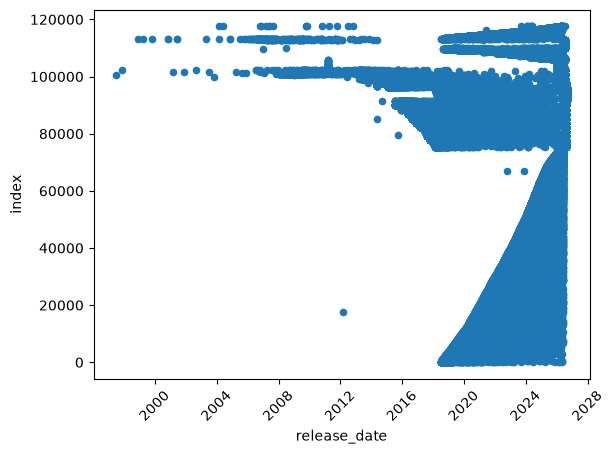

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10))
df.reset_index().plot(kind='scatter', x='release_date', y='index', rot=45)
plt.show()

### Let's solve some question a real quick:

##### 1). Find the popular game in recent 5 years:


Approach: 
- Using custom filters here from positive column as per our need
- Using Popularity column we have calculated before
- Using combination of recommendations and estimated_owners

Along with year column to filter last 5 years

In [109]:
# I would pick last one using combination of recommendations and estimated_owners

# First top 1000 recommendation range:
min_recoom, max_recomm = df.recommendations.nlargest(n=1000).iloc[[0, -1]]
recomm_filter = df.recommendations.between(min_recoom, max_recomm)

# Assigning category datatype:
df.estimated_owners = df.estimated_owners.astype('category')
owners_filter = df.estimated_owners.isin(['50000 - 100000', '500000 - 1000000', '5000000 - 10000000', '50000000 - 100000000'])

# Last five years filter:
years = df.year.isin(df.year.value_counts().index[:5])

# Combine both conditions:
interested_columns = ['name', 'release_date', 'price', 'popularity', 'price_status', 'estimated_owners', 'genres']
df.loc[ years & (owners_filter | recomm_filter), interested_columns].reset_index(drop=True).sort_values(by='release_date', ascending=False)

,name,release_date,price,popularity,price_status,estimated_owners,genres
399,Astro Colony,2026-06-02,19.99,Average,paid,50000 - 100000,"[""Action"", ""Adventure"", ""Casual"", ""Indie"", ""Si..."
1634,Wild Assault,2026-05-28,14.99,Average,paid,50000 - 100000,"[""Action"", ""Adventure"", ""Massively Multiplayer""]"
1541,Tower of Babel: Survivors of Chaos,2026-05-26,12.99,Average,paid,500000 - 1000000,"[""Action"", ""Adventure"", ""Indie"", ""RPG"", ""Strat..."
1486,Eden Crafters,2026-05-07,19.99,Average,paid,50000 - 100000,"[""Adventure"", ""Indie"", ""Simulation"", ""Strategy""]"
109,Kristala,2026-04-23,39.99,Low,paid,50000 - 100000,"[""Action"", ""Adventure"", ""Indie"", ""RPG""]"
...,...,...,...,...,...,...,...
652,Rising of the Moon - Part 1,2022-01-07,4.99,Extreme Low,paid,50000 - 100000,"[""Indie"", ""RPG""]"
649,RedPixel,2022-01-06,0.00,Extreme Low,free,50000 - 100000,"[""Adventure"", ""Indie""]"
298,Heaven Dust 2,2022-01-05,14.99,Below Average,paid,50000 - 100000,"[""Action"", ""Adventure"", ""Indie"", ""RPG""]"
263,天师,2022-01-04,8.99,Low,paid,50000 - 100000,[]


#### 2). Target top popular games which has Adventure, Racing, Simulation, Actions and Sporty in nature which are free

Approach:
- Filter down Adventure, Racing, etc categories
- Go with Free game
- Go with popularity

Question: Does order matters ?, let's check it out :)

In [119]:
# Previously calculated values from genres column:
list(genres_dict.values())

['Action',
 'Sports',
 'Strategy',
 'Early Access',
 'Free To Play',
 'Indie',
 'Casual',
 'Simulation',
 'Education',
 'Game Development',
 'Massively Multiplayer',
 'RPG',
 'Racing',
 'Adventure',
 'Utilities',
 'Movie',
 'Animation & Modeling',
 'Audio Production',
 'Design & Illustration',
 'Web Publishing',
 'Software Training',
 'Photo Editing',
 'Accounting',
 'Video Production',
 'Sexual Content',
 'Nudity',
 'Violent',
 'Gore']

In [139]:
# Genre Filter:
selected_genres = ['Action', 'Sports', 'Strategy', 'Adventure', 'Racing', 'Simulation', 'Gore']
genre_filter = df.genres.str.contains('|'.join(selected_genres), regex=True)

# Popularity Filter: 
popular_filter = df.popularity.isin(df.popularity.cat.categories[-6:])

# Price status filter:
price_filter = df.price_status == 'free'

In [ ]:
# Let's play around with order of filters now:
# 1. genre -> popularity -> free:
print(df.loc[genre_filter & popular_filter & price_filter, :].shape)

# 2. popularity -> free -> genre:
print(df.loc[popular_filter & price_filter & genre_filter, :].shape)

# 3. free -> genre -> popularity:
print(df.loc[price_filter & genre_filter & popular_filter, :].shape)

# Note: Hence proved order does not matters at all, Pandas backend strcuture written in a way that all operation 
# completed parallelly without order concerns.

(267, 28)
(267, 28)
(267, 28)
